In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile

with zipfile.ZipFile("/content/weapon detection cctv v3 dataset.v1-weapon_detection_in_cctv.yolov8.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted")

import os

print(os.listdir("/content/dataset"))

Saving weapon detection cctv v3 dataset.v1-weapon_detection_in_cctv.yolov8.zip to weapon detection cctv v3 dataset.v1-weapon_detection_in_cctv.yolov8.zip
Dataset extracted
['valid', 'test', 'data.yaml', 'train', 'README.dataset.txt', 'README.roboflow.txt']


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # fastest + best for quick training

model.train(
    data="/content/dataset/data.yaml",
    epochs=50,          # 🔥 instead of 80
    imgsz=640,
    batch=8,
    device=0,
    patience=5         # stops early if no improvement
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspect

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de6616958e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from google.colab import files
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

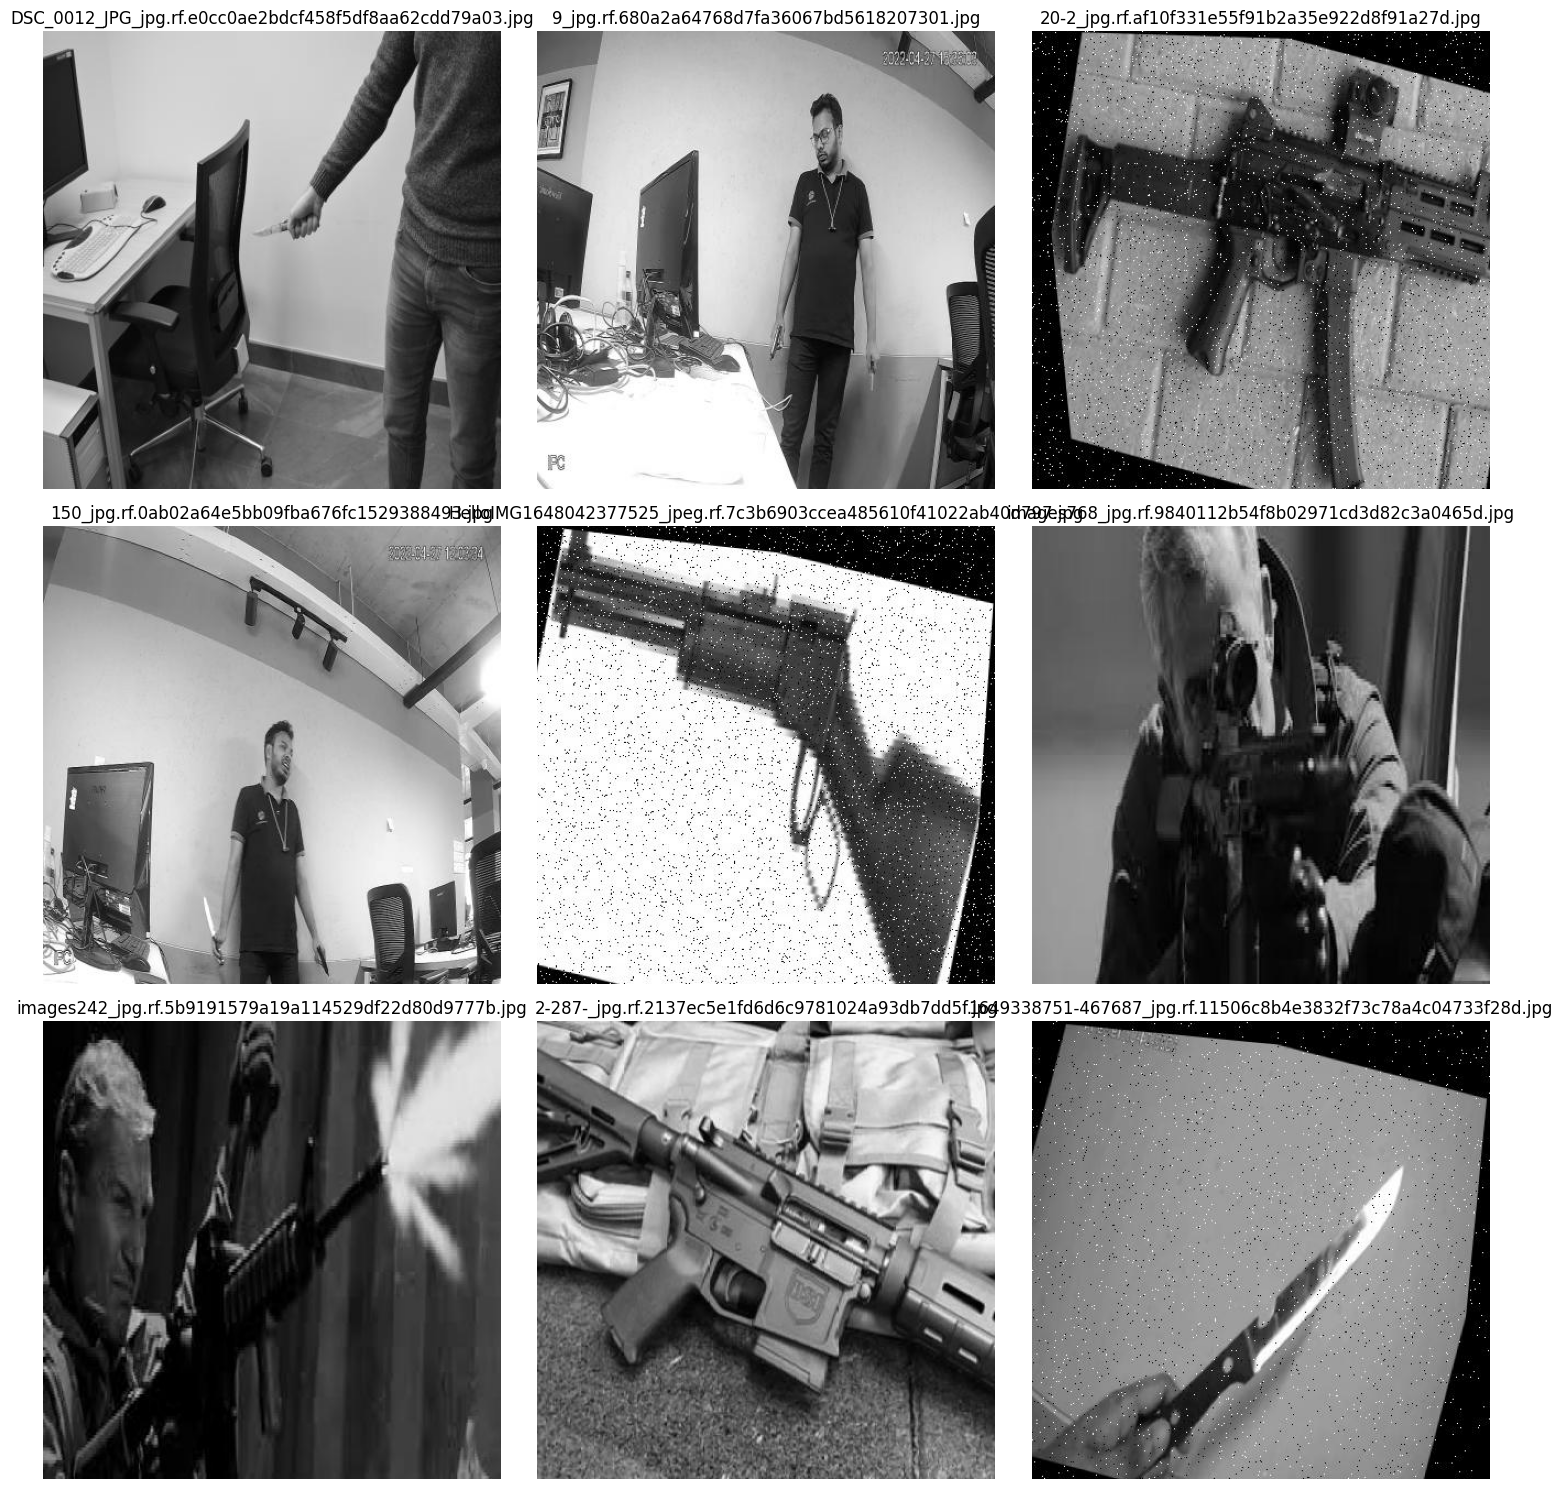

Saved to sample_training_images.png


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

img_dir = "/content/dataset/train/images"
images = os.listdir(img_dir)
sample = random.sample(images, 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, img_name in zip(axes.flatten(), sample):
    img = cv2.imread(os.path.join(img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_training_images.png")
plt.show()
print("Saved to sample_training_images.png")